#Hiren Patel
##Project 1: Exploratory Data Analysis of Historical Stock Market Data

#Part 1 — Load and Understand the Data

In [1]:
#import libraries
import pandas as pd

In [22]:
#Load datasets
historical_stocks = pd.read_csv("historical_stocks.csv")
historical_stock_prices = pd.read_csv("historical_stock_prices.csv")

In [23]:
#Display the first five rows
print("\n Historical_Stock")
historical_stocks.head()



 Historical_Stock


,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS


In [24]:
print("\n Historical_Stock_prices")
historical_stock_prices.head()


 Historical_Stock_prices


,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900.0,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800.0,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100.0,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400.0,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100.0,2013-05-14


In [25]:
#check the sape of database
print("\n Historical_Stock")
print(historical_stocks.shape)
print("\n Historical_Stock_prices")
print(historical_stock_prices.shape)


 Historical_Stock
(6460, 5)

 Historical_Stock_prices
(280514, 8)


In [26]:
#check the info of dataset
print("\n Historical_Stock")
print(historical_stocks.info())
print("\n Historical_Stock_prices")
print(historical_stock_prices.info())


 Historical_Stock
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ticker    6460 non-null   object
 1   exchange  6460 non-null   object
 2   name      6460 non-null   object
 3   sector    5020 non-null   object
 4   industry  5020 non-null   object
dtypes: object(5)
memory usage: 252.5+ KB
None

 Historical_Stock_prices
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280514 entries, 0 to 280513
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   ticker     280514 non-null  object 
 1   open       280514 non-null  float64
 2   close      280514 non-null  float64
 3   adj_close  280513 non-null  float64
 4   low        280513 non-null  float64
 5   high       280513 non-null  float64
 6   volume     280513 non-null  float64
 7   date       280513 non-null  object 
dtypes: float64(

##Interpration -
I loaded both files successfully — head() confirmed the data read in correctly.
My stocks file has 6,460 rows and 5 columns, all text — it holds the company info (ticker, exchange, name, sector, industry).
My prices file is much bigger — about 21 million rows and 8 columns — holding the daily price records.
I found 6 numeric columns in prices (open, high, low, close, adj_close, volume) and ticker as text; my stocks file is entirely text.
I noticed the date column is stored as an object (text), not a real date, so I'll need to convert it to datetime before doing any time-based analysis.
Using info(), I also checked the non-null counts, which gave me my first look at where missing values might be — something I'll handle in the cleaning step.

##ANSWER –
 ### What does each dataset represent?
-	I am working with the “Daily Historical Stock Prices (1970 - 2020)” dataset, which includes the following columns: Date, Open, High, Low, Close, Volume, and Adjusted Close in historical_stock_prices.csv and Ticker, exchange, name, sector, industry in the historical_stocks.csv. This dataset has daily stocks prices record form USA’s different stock exchanges.

 ### What is the purpose of the ticker column?
-	A ticker is the short code that stands for a company's stock on the market. Instead of writing the full company name every time, the market gives it a few-letter symbol. So in my data, the ticker column is basically the company's ID or nickname. And each company have 2 ticker one ticker give access to voting right and other ticker do not give access to voting right.

### How are the two datasets related?
-	I have 2 separate files, in one file I have daily stock prices updates from all listed companies with their company Id (ticker) and second file have company information including their exchange, sector, industry.
How many rows and columns does each dataset contain?
-	Historical Stocks file has 6460 rows and 5 columns and Historical stock prices have 127578 (approximately 1.27 million) rows and 8 columns.

### Which columns are numerical?
-	Historical Stocks file I have no numeric columns whereas the Historical stock prices have 6 numerical columns Open, High, Low, Close and Volume.

### Which columns are categorical?
-	In Historical Stocks file have 5 columns and all is categorical and columns name are Ticker, exchange, name, sector and industry.

### Which column represents the date?
-	In Historical stock prices has date columns but in dataset it’s data type is object so I need to change to datetime so we can perform some analysis.


#Part 2 — Check Data Quality

In [27]:
#missing values
print("\n Historical_Stock")
print(historical_stocks.isnull().sum())
print("\n Historical_Stock_prices")
print(historical_stock_prices.isnull().sum())



 Historical_Stock
ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64

 Historical_Stock_prices
ticker       0
open         0
close        0
adj_close    1
low          1
high         1
volume       1
date         1
dtype: int64


In [28]:
#check the duplicate data
print("\n Historical_Stock")
print(historical_stocks.duplicated().sum())
print("\n Historical_Stock_prices")
print(historical_stock_prices.duplicated().sum())


 Historical_Stock
0

 Historical_Stock_prices
0


In [29]:
#check the dubplicte usning the ticker column
check_duplicate = historical_stock_prices.duplicated(subset=['ticker', 'date']).sum()
print("\n Historical_Stock_prices")
print(check_duplicate)


 Historical_Stock_prices
0


In [34]:
#ticker column dara quality in historicale stock price csv
print("\n Historical_Stock_prices")
print(historical_stock_prices['ticker'].head(10))
print(historical_stock_prices['ticker'].value_counts())
print(historical_stock_prices['ticker'].nunique())


 Historical_Stock_prices
0    AHH
1    AHH
2    AHH
3    AHH
4    AHH
5    AHH
6    AHH
7    AHH
8    AHH
9    AHH
Name: ticker, dtype: object
ticker
GTY      9729
RRD      9696
AAPL     9507
RAVN     9080
AMSWA    8948
         ... 
HIBB      139
KTOV      110
GNPX      102
APY        77
RRR         2
Name: count, Length: 78, dtype: int64
78


In [31]:
#ticker column dara quality in historicale stocks csv
print("\n Historical_Stock")
print(historical_stocks['ticker'].head(10))
print(historical_stocks['ticker'].value_counts())
print(historical_stocks['ticker'].nunique())


 Historical_Stock
0      PIH
1    PIHPP
2     TURN
3     FLWS
4     FCCY
5     SRCE
6     VNET
7     TWOU
8     JOBS
9     CAFD
Name: ticker, dtype: object
ticker
ZYME     1
PIH      1
PIHPP    1
TURN     1
FLWS     1
        ..
ABIL     1
ABEOW    1
ABEO     1
ABAX     1
AAON     1
Name: count, Length: 6460, dtype: int64
6460


In [35]:
#sector column dara quality in historicale stocks csv
print("\n Historical_Stock")
print(historical_stocks['sector'].head(10))
print(historical_stocks['sector'].value_counts())
print(historical_stocks['sector'].nunique())


 Historical_Stock
0              FINANCE
1              FINANCE
2              FINANCE
3    CONSUMER SERVICES
4              FINANCE
5              FINANCE
6           TECHNOLOGY
7           TECHNOLOGY
8           TECHNOLOGY
9     PUBLIC UTILITIES
Name: sector, dtype: object
sector
FINANCE                  1022
CONSUMER SERVICES         796
HEALTH CARE               784
TECHNOLOGY                607
CAPITAL GOODS             352
ENERGY                    286
PUBLIC UTILITIES          273
BASIC INDUSTRIES          272
CONSUMER NON-DURABLES     224
CONSUMER DURABLES         144
MISCELLANEOUS             139
TRANSPORTATION            120
SECTOR                      1
Name: count, dtype: int64
13


In [41]:
#want to see the full row whree sector = SECTOR
print("\n Historical_Stock")
print(historical_stocks[historical_stocks['sector'] == 'SECTOR'])


 Historical_Stock
    ticker exchange  name  sector  industry
74  Symbol     NYSE  NAME  SECTOR  INDUSTRY


In [37]:
#cheking the incorrect record in the History stock prices
hsp = historical_stock_prices

In [38]:
#checking zero or negative stock prices
print("\n Historical_Stock_prices")
neg_prices = (hsp[['open','high','low','close','adj_close']] <= 0).any(axis=1)
print("bad rows:", neg_prices.sum())
hsp.loc[neg_prices, ['ticker','date','open','high','low','close','volume']]


 Historical_Stock_prices
bad rows: 0


,ticker,date,open,high,low,close,volume


In [40]:
# check the negative volume
print("rows with negative volume:", (hsp['volume'] < 0).sum())

# zero volume — possible (no trading that day) but worth noting
print("rows with zero volume:", (hsp['volume'] == 0).sum())

rows with negative volume: 0
rows with zero volume: 0


###Interpriation
I checked both files (HS = historical_stocks, HSP = historical_stock_prices) for data-quality problems.

Missing values: I used isnull().sum() on both files. In the HS file, I found 1,440 missing values in sector and 1,440 in industry. In the HSP file, I found 1 missing value each in adj_close, low, high, volume, and date — so basically one broken row where several fields are blank. The missing sectors and industries are not necessarily errors; some companies just don't have that information filled in.

Duplicates: I checked for fully duplicate rows in both files and found none. I also checked for duplicate ticker + date combinations in the HSP file (the same stock on the same day), and found 0 — so there are no repeated price records.

Checking the HS (categorical) file: Every column except none is categorical here, so I inspected each column manually using head(), value_counts(), and nunique(). I found something suspicious in the sector column — there was a value called SECTOR, which isn't a real sector. I looked at the full row and found a bug at row index 74: the whole row contained junk header words instead of real company data.

Checking the HSP (numerical) file: Since this file is all numbers, I checked whether any stock price was 0 or negative, because in reality a price can't be zero or below. I found none — the price data looks clean. Then I checked the volume column: volume can't be negative, and I also looked for zero-volume days (a stock might not trade on some days for various reasons). Both checks returned 0 rows, so the volume data is in good shape for now.

My conclusion: The data is mostly clean. The clear problems I need to handle are: the junk row (index 74) in the HS file, the missing sector/industry values, and the one broken row in the HSP file. I'll decide how to treat each in the cleaning step, and I won't delete anything just because it looks unusual.

###1. Which columns contain missing values?
In the HS file, sector and industry have missing values. In the HSP file, adj_close, low, high, volume, and date each have a missing value.

###2. How many missing values are there?
In the HS file, I found 1,440 missing in sector and 1,440 in industry. In the HSP file, I found 1 missing value in each of adj_close, low, high, volume, and date — which looks like a single broken row.

###3. Are missing values necessarily errors? Explain.
No, they are not always errors. Sometimes data is simply not recorded or not available. For example, the missing sector and industry values just mean that information was never filled in for those companies — that's not a mistake in the data, it's just incomplete. But the missing values in the HSP file (a whole row missing several fields) look more like a real problem, so I need to investigate that one.

###4. Are there duplicate rows?
No. I checked both files with duplicated().sum() and found no fully duplicate rows.

###5. Are there duplicate ticker + date combinations?
No. I checked the HSP file for the same ticker on the same date and found 0, so there are no repeated price records for any stock on any day.

###6. Did you find any obvious data-quality problems?
Yes, two. First, in the HS file there is a junk row at index 74 where the sector value is literally SECTOR and the whole row contains header-like words instead of real company data. Second, in the HSP file there is one broken row with several missing values (including the date). Both are things I'll deal with in the cleaning step — carefully, without deleting anything just because it looks unusual.

#Part 3 — Prepare and Explore the Date

In [46]:
#Convert date to datetime
hsp['date'] = pd.to_datetime(hsp['date'])
print(hsp.dtypes['date'])

datetime64[ns]


In [47]:
#make sure the all date is in same formate
hsp['date'] = pd.to_datetime(hsp['date'], format='%Y-%m-%d', errors = 'coerce')
print ("missing value", hsp['date'].isnull().sum())


missing value 1


In [48]:
# find the earliest and last date of the data
print("earliest date:", hsp['date'].min())
print("latest date:  ", hsp['date'].max())

earliest date: 1972-06-01 00:00:00
latest date:   2018-08-24 00:00:00


###Interpritation -
I converted the date column from object to datetime using pd.to_datetime. I then checked the date format and confirmed all dates follow the same format, with only 1 missing value (NaT) — the broken row I already knew about from Part 2. After converting, I found the earliest date is 1972-06-01 and the latest is 2018-08-24, so my data covers about 46 years of daily stock prices.

###1. What is the date range of the dataset?
My data runs from 1972-06-01 to 2018-08-24, which is about 46 years of daily stock prices.

###2. Why is it useful to convert a date column to datetime?
When a date is stored as text (object), Python just sees it as words, so I can't do any real date maths with it. Converting it to datetime makes Python actually understand it as a date. Then I can sort by date properly, find the earliest and latest dates, filter by year, and pull out parts like the month, year, or decade. Without converting, things like min() and max() only work by accident (alphabetical order), and most time-based tools won't work at all.

###3. What types of analysis become easier when working with datetime values?
A lot becomes easier once the date is real datetime:

Filtering data to a specific year or date range
Grouping by month, year, or decade (which I'll need for the decade analysis)
Resampling daily prices into monthly or yearly averages
Plotting time-series charts (price over time)
Measuring gaps or time between dates

Basically, any analysis that involves time — trends, seasonality, comparing periods — only works smoothly when the date column is proper datetime.

#Part 4 — Explore Categorical Data

In [81]:
#imported all libreries which is used for visulisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as px

exchange
NASDAQ    3308
NYSE      3152
Name: count, dtype: int64


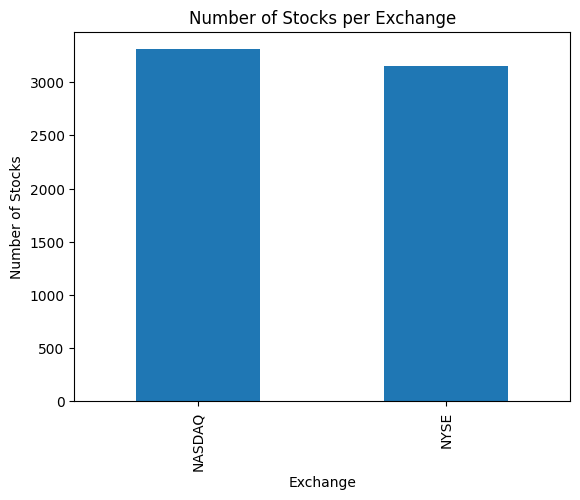

In [55]:
#creating bar chart - number of stocks associalted with the excnaghe
exchanges = historical_stocks['exchange'].value_counts()
print(exchanges)
exchanges.plot(kind='bar')
plt.xlabel('Exchange')
plt.ylabel('Number of Stocks')
plt.title('Number of Stocks per Exchange')
plt.show()

###Interpritation
I counted the number of securities on each exchange and made a bar chart. The two exchanges are very close in size — NASDAQ has slightly more. Both are major U.S. exchanges, so it makes sense they dominate the dataset.

###1. Which exchanges are represented?
Two exchanges: NASDAQ and NYSE.

###2. How many securities are associated with each exchange?
NASDAQ has 3,308 securities and NYSE has 3,152.

###3. Which exchange has more securities in this dataset?
NASDAQ has more, with 3,308 vs NYSE's 3,152 — a difference of 156.

sector
FINANCE                  1022
CONSUMER SERVICES         796
HEALTH CARE               784
TECHNOLOGY                607
CAPITAL GOODS             352
ENERGY                    286
PUBLIC UTILITIES          273
BASIC INDUSTRIES          272
CONSUMER NON-DURABLES     224
CONSUMER DURABLES         144
MISCELLANEOUS             139
TRANSPORTATION            120
SECTOR                      1
Name: count, dtype: int64


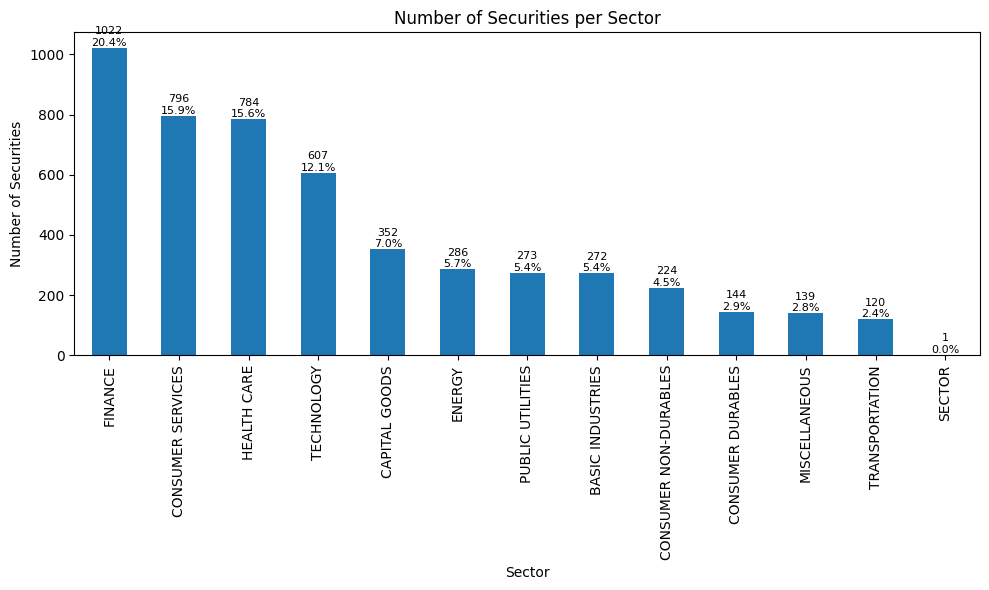

In [56]:
#creating bar chart - number of stocks associalted with the sector
sectors = historical_stocks['sector'].value_counts()
print(sectors)

# total securities that HAVE a sector
total_sector = sectors.sum()
ax = sectors.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Sector')
plt.ylabel('Number of Securities')
plt.title('Number of Securities per Sector')

# put count + percentage on top of each bar
for i, v in enumerate(sectors):
    ax.text(i, v, f"{v}\n{v/total_sector*100:.1f}%", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

###Interpretation:

Looking at the data, the largest sector is Finance with 1,022 securities, which is 20.4% of all listed securities. Consumer Services and Health Care are almost equal, each with about 800 securities (15.5%). Technology has 607 (12%). Energy, Public Utilities, and Basic Industries are all similar in size, each contributing roughly 5%. The remaining four sectors each contribute below 5%, with fewer than 300 securities each. So the dataset is fairly top-heavy — Finance, Consumer Services, Health Care, and Technology together make up most of the securities.

###1. Which sectors contain the most securities?
Finance is the largest (1,022, 20.4%), followed by Consumer Services (796, 15.9%) and Health Care (784, 15.6%), then Technology (607, 12.1%). These four dominate the dataset.

###2. How many securities have missing sector information?
1,440 securities have no sector listed (these show as NaN and aren't counted in the chart).

###3. What might be some reasons for missing sector information?
A few likely reasons: the data source may simply not have recorded a sector for those companies; some may be securities that don't fit a standard sector (like funds, warrants, or preferred shares rather than normal company stock); some may be older, delisted, or foreign listings where the sector was never classified; or it's just a gap in how the dataset was collected.

#Part 5 — Explore Numerical Data


In [57]:
#check the stastics of all numeric valuse in HSP
hsp.describe().round(2)

,open,close,adj_close,low,high,volume,date
count,280514.000000,280514.000000,280513.000000,280513.000000,280513.000000,2.805130e+05,280513
mean,22.396354,22.390253,18.906445,21.984214,22.785304,3.675842e+06,2005-11-16 07:10:05.760160896
min,0.007000,0.007000,0.000015,0.007000,0.007000,1.000000e+00,1972-06-01 00:00:00
25%,6.460000,6.456200,3.815622,6.320000,6.590000,2.260000e+04,1999-09-22 00:00:00
50%,13.500000,13.500000,9.172477,13.300000,13.690000,1.073000e+05,2007-11-27 00:00:00
75%,25.219999,25.200001,20.076027,24.930000,25.500000,5.215000e+05,2013-11-18 00:00:00
max,1550.000000,1578.750000,1578.750000,1360.000000,1635.000000,1.855410e+09,2018-08-24 00:00:00
std,37.908436,37.839415,37.721318,36.572364,39.102296,2.268923e+07,NaN


In [58]:
hsp.select_dtypes('number').describe().round(2)

,open,close,adj_close,low,high,volume
count,280514.00,280514.00,280513.00,280513.00,280513.00,2.805130e+05
mean,22.40,22.39,18.91,21.98,22.79,3.675842e+06
std,37.91,37.84,37.72,36.57,39.10,2.268923e+07
min,0.01,0.01,0.00,0.01,0.01,1.000000e+00
25%,6.46,6.46,3.82,6.32,6.59,2.260000e+04
50%,13.50,13.50,9.17,13.30,13.69,1.073000e+05
75%,25.22,25.20,20.08,24.93,25.50,5.215000e+05
max,1550.00,1578.75,1578.75,1360.00,1635.00,1.855410e+09


In [59]:
pd.set_option('display.float_format', '{:,.2f}'.format)
hsp[['open', 'high', 'low', 'close', 'volume']].describe()

,open,high,low,close,volume
count,"280,514.00","280,513.00","280,513.00","280,514.00","280,513.00"
mean,22.40,22.79,21.98,22.39,"3,675,841.89"
std,37.91,39.10,36.57,37.84,"22,689,226.06"
min,0.01,0.01,0.01,0.01,1.00
25%,6.46,6.59,6.32,6.46,"22,600.00"
50%,13.50,13.69,13.30,13.50,"107,300.00"
75%,25.22,25.50,24.93,25.20,"521,500.00"
max,"1,550.00","1,635.00","1,360.00","1,578.75","1,855,410,200.00"


To explore the numerical data, I used the describe() function in three ways. First, I ran a basic describe() to get the summary statistics (count, mean, std, min, quartiles, and max). Because describe() also picked up non-numeric columns, I used select_dtypes('number').describe() to show only the numeric columns and exclude the date. Finally, I used pd.set_option('display.float_format', ...) to change how the numbers displayed, so the large volume values showed as full numbers instead of scientific notation, making the results easier to read.

###Interpretation:
Open:

The minimum open price is 0.01 and the maximum is 1,550, so all opening prices fall between these. The mean open price is 22.40, but the median is only 13.50 — the mean is higher than the median, which means a few very expensive stocks are pulling the average up. The standard deviation is 37.91, larger than the mean, showing the prices are widely spread. Looking at the quartiles, 25% of stocks open below $6.46, half open below $13.50, and 75% open below $25.22 — so most stocks are actually low-priced, and only a small number are very expensive (up to $1,550).

High:

The minimum high price is 0.01 and the maximum is 1,635. The mean high is 22.79, but the median is only 13.69, so the mean sits above the median — a few very expensive stocks pull the average up. The standard deviation is 39.10, larger than the mean, showing the prices are widely spread. From the quartiles, 25% of stocks have a high below $6.59, half are below $13.69, and 75% are below $25.50. So most daily highs are low, with only a small number reaching very high values.

Low:

The minimum low price is 0.01 and the maximum is 1,360. The mean low is 21.98 and the median is 13.30, so again the mean is higher than the median — the same right-skew from a few expensive stocks. The standard deviation is 36.57, larger than the mean, showing a wide spread. Looking at the quartiles, 25% of low prices are below $6.32, half are below $13.30, and 75% are below $24.93. Most daily lows are small, with a few large outliers.

Close:

The minimum close price is 0.01 and the maximum is 1,578.75. The mean close is 22.39 while the median is 13.50, so the mean is pulled above the median by expensive stocks. The standard deviation is 37.84, larger than the mean, showing prices are widely spread. From the quartiles, 25% of stocks close below $6.46, half close below $13.50, and 75% close below $25.20. This confirms most stocks are low-priced, with only a small number very expensive.

Volume:

The minimum volume is 1 share and the maximum is over 1.85 billion. The mean volume is about 3.68 million, but the median is only 107,300 — the mean is roughly 34 times the median, so this column is extremely skewed. The standard deviation is about 22.7 million, far larger than the mean, meaning volume varies enormously. From the quartiles, 25% of days have volume below 22,600, half are below 107,300, and 75% are below 521,500. So on most days trading is fairly light, but a small number of days have massive trading volume that stretches the average way up.

###1. What is the mean closing price?
The mean closing price is $22.39.

###2. What is the median closing price?
The median closing price is $13.50 (the 50% value).

###3. How different are the mean and median?
The mean ($22.39) is about $8.89 higher than the median ($13.50) — the mean is roughly 1.7 times the median, so there's a clear gap.

###4. Which variable has the largest standard deviation?
Volume, by a huge margin — its std is about 22.7 million, far larger than any price column (the price columns are all under 40).

###5. Which variables contain very large maximum values?
Volume has the most extreme max (over 1.85 billion shares). The price columns also have large maxes compared to their medians — high reaches 1,635, close reaches 1,578.75, open 1,550, low 1,360 — all far above their ~$13 medians.

###6. What might the difference between the mean and median tell you about the data?
It tells me the data is right-skewed. Because the mean is higher than the median, a small number of very expensive stocks (and very high-volume days) are pulling the average up, while most stocks sit at lower prices. In short, the data isn't evenly spread — it has a long tail of extreme high values, so the median is a more reliable "typical" value than the mean here.

#Part 6 — Investigate Unusual Values

In [72]:
#Find the observations with the highest close values.
top_close = hsp.sort_values('close', ascending=False).head(10)
print(top_close[['ticker', 'date', 'open', 'high', 'low', 'close', 'volume']])

print("compney deatils")
print (historical_stocks[historical_stocks['ticker'] == "KTOS"])

       ticker       date     open     high      low    close    volume
216840   KTOS 2000-03-06 1,500.00 1,635.00 1,340.00 1,578.75 29,300.00
216844   KTOS 2000-03-07 1,550.00 1,588.75 1,241.25 1,523.12 31,800.00
216892   KTOS 2000-03-10 1,360.00 1,570.00 1,360.00 1,438.75 20,700.00
216858   KTOS 2000-03-08 1,450.00 1,510.00 1,310.00 1,418.75 14,800.00
216910   KTOS 2000-03-14 1,335.00 1,455.00 1,260.00 1,380.00 28,400.00
216914   KTOS 2000-03-15 1,421.56 1,440.00 1,250.00 1,380.00 19,200.00
216862   KTOS 2000-03-09 1,353.75 1,450.00 1,343.12 1,350.00 10,200.00
216933   KTOS 2000-03-16 1,336.25 1,420.00 1,300.00 1,320.62 19,800.00
216991   KTOS 2000-03-27 1,230.00 1,296.88 1,187.50 1,296.88  8,000.00
216896   KTOS 2000-03-13 1,300.00 1,442.50 1,240.00 1,288.75 18,900.00
compney deatils
     ticker exchange                                       name  \
1770   KTOS   NASDAQ  KRATOS DEFENSE & SECURITY SOLUTIONS, INC.   

             sector                       industry  
1770  CAPITAL G

###Interpretation:
I found that the company with the highest closing prices is Kratos Defense & Security Solutions, Inc., listed on NASDAQ under the ticker KTOS, in the Capital Goods sector and the Military/Government/Technical industry. All of the top 10 highest closing prices belong to this single stock, and they all occurred in March 2000. The highest close was $1,578.75 on 2000-03-06, with 29,300 shares traded that day; on that day the price reached a high of $1,635 and a low of $1,340 — about a $295 swing in a single day, which is large. Because all ten highest values come from the same stock across consecutive trading days, and the prices move smoothly from one day to the next, they look like real historical prices, not data errors — a random error wouldn't produce a clean run of similar values over consecutive days. To explain why the price was so high, I would need extra information such as company news, a possible stock split, or anyother event.

###1. Which securities have the highest closing prices?
All of the top 10 highest closing prices belong to one stock — KTOS (Kratos Defense & Security Solutions, Inc.), listed on NASDAQ in the Capital Goods sector.

###2. When did these observations occur?
They all occurred in March 2000, over a run of consecutive trading days (from 2000-03-06 to 2000-03-27).

###3. What was the trading volume?
The trading volume on those days was fairly low — ranging from about 8,000 to 31,800 shares. On the highest close day (2000-03-06, close $1,578.75), volume was 29,300 shares.

###4. Do the observations appear unusual?
Yes, at first glance they look unusual because the prices (over $1,500) are far above the median close of about $13.50. But they're consistent — all from the same stock, moving smoothly across consecutive days.

###5. Can you conclude that they are errors? Why or why not?
No, I cannot conclude they are errors. A single high price doesn't mean the data is wrong — some stocks really do trade at very high prices. The fact that all ten values belong to the same company (KTOS) and move gradually day-to-day, rather than being random spikes, strongly suggests they are real historical prices. A genuine error would look random and isolated, not like a smooth run of similar values. To fully explain the high price I'd need external information (like a stock split or company news), but based on the data alone, I would keep these records, not delete them.

In [76]:
(hsp.sort_values('close', ascending=False)
    .drop_duplicates(subset='ticker')
    .head(10)[['ticker','date','open','high','low','close','volume']])

,ticker,date,open,high,low,close,volume
216840,KTOS,2000-03-06,"1,500.00","1,635.00","1,340.00","1,578.75","29,300.00"
34184,VIAV,2000-03-06,643.91,686.29,643.91,666.81,"4,242,700.00"
187643,OLD,2008-04-22,468.82,468.82,468.82,468.82,29.00
177100,ANIP,2004-11-29,368.64,392.04,367.20,375.84,"15,400.00"
133906,VTNR,2000-02-15,360.00,480.00,324.00,360.00,"2,600.00"
251841,ICUI,2018-06-14,307.25,309.85,305.15,309.75,"135,200.00"
250616,MHK,2017-12-01,283.10,286.29,279.09,284.82,"653,600.00"
215688,LLEX,2009-10-27,220.00,220.00,220.00,220.00,500.00
100490,AAPL,2018-08-17,213.44,217.95,213.16,217.58,"35,427,000.00"
228702,ADMP,1999-11-22,178.50,184.88,174.25,184.88,"3,800.00"


In [77]:
#Filter to just KTOS and describe its own close prices
ktos = hsp[hsp['ticker'] == 'KTOS']
print(ktos['close'].describe())

count   4,731.00
mean       68.41
std       158.16
min         2.99
25%         7.45
50%        13.50
75%        57.65
max     1,578.75
Name: close, dtype: float64


To be more concrete, I checked the descriptive statistics for KTOS only. Its median close is just $13.50 and its minimum is $2.99, but its maximum is $1,578.75 — so most of the time this stock traded around $13, and only during March 2000 did it spike to over $1,500 before falling back down. The mean ($68.41) sits far above the median, and the standard deviation ($158.16) is very large, both showing that a short high-price period pulled the numbers up. Because these high values are the top end of KTOS's own real price history — a genuine rise and fall, not isolated random spikes — I'm confident they are real prices, not errors.

##6.2 Adjusted Closing Price


In [79]:
# largest adjusted closing values, comparing adj_close vs close
top_adj = hsp.sort_values('adj_close', ascending=False).head(10).copy()
top_adj['difference'] = top_adj['adj_close'] - top_adj['close']
top_adj[['ticker', 'date', 'close', 'adj_close', 'difference', 'volume']]

,ticker,date,close,adj_close,difference,volume
216840,KTOS,2000-03-06,"1,578.75","1,578.75",0.00,"29,300.00"
216844,KTOS,2000-03-07,"1,523.12","1,523.12",0.00,"31,800.00"
216892,KTOS,2000-03-10,"1,438.75","1,438.75",0.00,"20,700.00"
216858,KTOS,2000-03-08,"1,418.75","1,418.75",0.00,"14,800.00"
216910,KTOS,2000-03-14,"1,380.00","1,380.00",0.00,"28,400.00"
216914,KTOS,2000-03-15,"1,380.00","1,380.00",0.00,"19,200.00"
216862,KTOS,2000-03-09,"1,350.00","1,350.00",0.00,"10,200.00"
216933,KTOS,2000-03-16,"1,320.62","1,320.62",0.00,"19,800.00"
216991,KTOS,2000-03-27,"1,296.88","1,296.88",0.00,"8,000.00"
216896,KTOS,2000-03-13,"1,288.75","1,288.75",0.00,"18,900.00"


###Interpretation -
Just like the closing-price check, all top 10 highest adj_close values belong to the same company, KTOS, in March 2000. I added a new column called difference (adj_close − close), and all the values are 0 — meaning there was no gap between the close and adjusted close on those days. This makes sense: there was likely no dividend or stock split during that period, so no adjustment was needed

In [80]:
# check the top adjusted diffrance from the diffrance comapnies wit a real
# adjussment
top_adj_diff = hsp.sort_values('adj_close', ascending=False).drop_duplicates('ticker').head(10).copy()
top_adj_diff['difference'] = top_adj_diff['adj_close'] - top_adj_diff['close']
top_adj_diff[['ticker', 'date', 'close', 'adj_close', 'difference', 'volume']]

,ticker,date,close,adj_close,difference,volume
216840,KTOS,2000-03-06,"1,578.75","1,578.75",0.00,"29,300.00"
34184,VIAV,2000-03-06,666.81,666.81,0.00,"4,242,700.00"
187643,OLD,2008-04-22,468.82,441.87,-26.95,29.00
177100,ANIP,2004-11-29,375.84,375.84,0.00,"15,400.00"
133906,VTNR,2000-02-15,360.00,360.00,0.00,"2,600.00"
251841,ICUI,2018-06-14,309.75,309.75,0.00,"135,200.00"
250616,MHK,2017-12-01,284.82,284.82,0.00,"653,600.00"
215725,LLEX,2009-11-03,220.00,220.00,0.00,"2,800.00"
100490,AAPL,2018-08-17,217.58,217.58,0.00,"35,427,000.00"
228702,ADMP,1999-11-22,184.88,184.88,0.00,"3,800.00"


When I looked at the highest adj_close values across 10 different companies, I saw a mix of well-known real stocks — KTOS, VIAV, AAPL, MHK, ICUI, and others — trading at genuinely high prices. Most of them have a difference of 0, meaning their close and adjusted close were the same on that day (no dividend or split effect). However, one stock, OLD on 2008-04-22, shows a difference of −26.95 (close $468.82 vs adj_close $441.87). This means its adjusted close is lower than its close, which happens when the price is adjusted for a dividend or split. Seeing this real adjustment on one stock, and recognizable companies like Apple in the list, confirms that the large adj_close values are real market data, not errors.

###1. Which ticker(s) have very large adjusted closing values?
The single largest is KTOS (adj_close $1,578.75), followed by VIAV ($666.81). Across different companies, other high ones include OLD ($441.87), ANIP ($375.84), VTNR ($360.00), ICUI ($309.75), MHK ($284.82), and even Apple (AAPL) at $217.58.

###2. How do close and adj_close compare?
For most stocks the two are equal (difference = 0), meaning no dividend or split affected that day. The exception is OLD on 2008-04-22, where adj_close ($441.87) is lower than close ($468.82) — a difference of −$26.95 — because the price was adjusted for a dividend or split. So adj_close is either equal to or slightly below close, which is exactly how it should behave.

###3. When do the unusual values occur?
They occur on scattered dates across the whole range — from 1999 (ADMP) and 2000 (KTOS, VIAV, VTNR) up to 2018 (ICUI, AAPL). They aren't all clustered in one period; the top KTOS/VIAV values are from March 2000 (the dot-com peak).

###4. Do the values appear unusual?
At first glance yes, because they're far above the median adj_close of ~$13. But they belong to real, recognizable companies (like Apple and Mohawk) trading at genuinely high prices, so they're not truly abnormal — just high-priced stocks.

###5. Should they automatically be deleted? Explain your reasoning.
No, they should not be automatically deleted. A large value is not the same as an error. These are real companies, the adj_close values are consistent with their close prices, and the one non-zero difference (OLD) actually proves the adjustment logic is working correctly. Deleting them would remove valid data.

#Part 7 — Visualize the Data


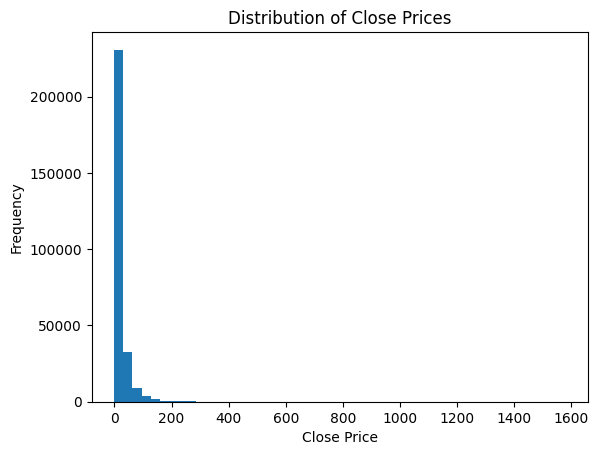

In [90]:
#Create a histogram of close.
plt.hist(hsp['close'], bins=50)
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.title('Distribution of Close Prices')
plt.show()

###Interpretation
The histogram shows that the vast majority of closing prices are low — most fall between $0 and $50, which is by far the tallest bar (around 230,000 records). The frequency drops sharply after that, and prices above $150 are very rare, forming a long thin tail stretching to about $1,600. This shows the distribution is strongly right-skewed (not symmetric): most stocks are inexpensive, while only a small number trade at very high prices. This matches my Part 5 statistics, where the mean close ($22.39) was higher than the median ($13.50) — those few expensive stocks in the right tail pull the average up.

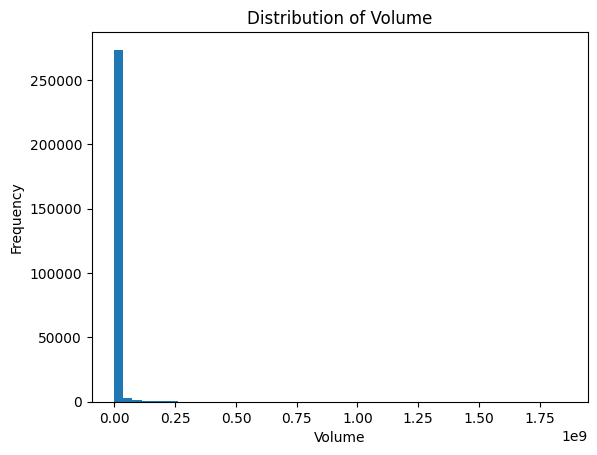

In [91]:
#Create a histogram of volume.
plt.hist(hsp['volume'], bins=50)
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.title('Distribution of Volume')
plt.show()

###Interpretation
The volume histogram is even more strongly right-skewed than the closing price. Almost all the trading days sit in the very first bar near zero — about 270,000 records — while the rest of the chart is nearly empty. The x-axis runs all the way up to about 1.85 billion shares (the "1e9" means billions), but those high-volume days are so rare they're barely visible as a tiny tail on the right. This tells me that on most days trading volume is relatively low, and only a very small number of days had massive trading activity. It matches my Part 5 statistics, where the mean volume (about 3.7 million) was far higher than the median (107,300) — those few extremely high-volume days pull the average up. So volume has an even longer, more extreme right tail than price.

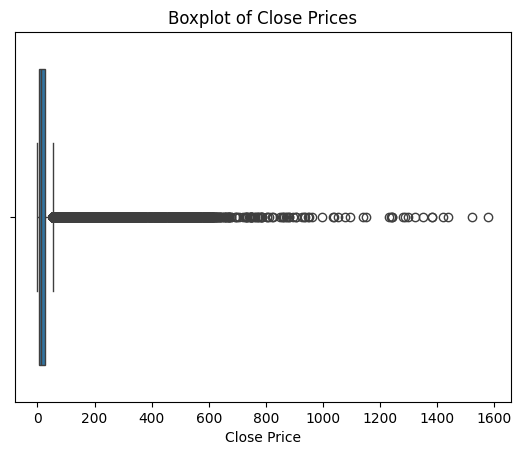

In [92]:
#Create a boxplot of close.
sns.boxplot(x=hsp['close'])
plt.xlabel('Close Price')
plt.title('Boxplot of Close Prices')
plt.show()

###Interpretation
I used the boxplot to identify outliers. It shows that the box — the middle 50% of closing prices — is squeezed into a very small range near $0–50, with the median around $13.50. This confirms most stocks are low-priced. The many dots stretching from about $50 all the way to $1,580 are statistical outliers — points far above the typical range. However, these outliers are not errors; they are real stocks that genuinely trade at high prices (like KTOS, which I investigated earlier). So the boxplot flags them as unusual, but from my Part 6 investigation I know they are valid data, not mistakes.

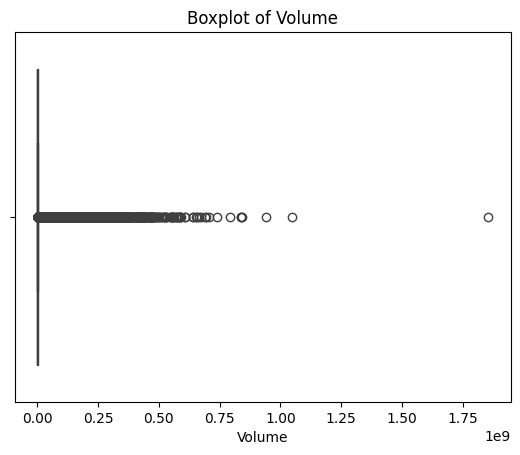

In [94]:
#Create a boxplot of volume.
sns.boxplot(x=hsp['volume'])
plt.xlabel('Volume')
plt.title('Boxplot of Volume')
plt.show()

###Interpretation
The volume boxplot shows an even more extreme pattern than the closing price. The box (the middle 50% of trading days) is squeezed so tightly against zero that it's barely visible, because most days have low volume (median around 107,300 shares). Beyond the whisker there is a huge cloud of outlier dots stretching all the way to about 1.85 billion shares, with one lone point far out on the right at the maximum. These high-volume days are statistical outliers, but from my earlier investigation I know they are not errors — they are real days when a stock traded unusually heavily (for example around major news or market events). So the boxplot confirms that trading volume is extremely right-skewed, with most days being quiet and a small number of days having massive activity.

###1. What does the distribution of closing prices look like?
The closing price distribution is heavily concentrated on the low end. The vast majority of prices fall between $0 and $50 (one tall bar of about 230,000 records), and the frequency drops off sharply after that, with a long thin tail stretching out to about $1,600.

###2. Is it approximately symmetric or skewed?
It is clearly right-skewed (positively skewed), not symmetric. Most values are small and bunched on the left, with a few large values pulling a long tail to the right.

###3. Are there extreme values?
Yes. There are extreme high values — some closing prices reach into the hundreds and even over $1,500 (like KTOS). They're rare, but they stretch the distribution far to the right.

###4. What does the volume distribution look like?
Volume is even more strongly right-skewed than price. Almost all trading days sit in the very first bar near zero, while a small number of days reach up to about 1.85 billion shares. So most days have low volume, with a few days of massive activity.

###5. What do the boxplots tell you about potential outliers?
The boxplots show that the middle 50% of both price and volume is squeezed into a very small range near the low end, with the median close to the bottom. Beyond the whiskers there are many outlier dots. For close, these stretch from about $50 up to $1,580; for volume, up to 1.85 billion. These are statistical outliers, but from my Part 6 investigation I know they are real data, not errors — so they should be kept, not deleted.

###6. How do the visualizations compare with your descriptive statistics?
They match my Part 5 statistics closely. There, the mean was higher than the median for every column (e.g. close mean $22.39 vs median $13.50; volume mean 3.7M vs median 107,300), which signals right-skew — and the charts show exactly that shape. The large maximums and high standard deviations from the stats appear visually as the long right tails and the outlier dots. So the numbers and the pictures tell the same story: the data is right-skewed with a small number of extreme high values.

#Part 8 — Explore One Stock and Summarize Your Findings


In [112]:
#finsd the comney deatils from the ticker
historical_stocks[historical_stocks['ticker'] == 'KTOS']

,ticker,exchange,name,sector,industry
1770,KTOS,NASDAQ,"KRATOS DEFENSE & SECURITY SOLUTIONS, INC.",CAPITAL GOODS,MILITARY/GOVERNMENT/TECHNICAL


In [98]:
#pic the one ticker and filter that
ticker = 'KTOS'
ticker_data = hsp[hsp['ticker'] == ticker]
print(ticker_data.head(10))

       ticker   open  close  adj_close    low   high       volume       date
216123   KTOS 150.00 620.00     620.00 150.00 690.00 1,412,100.00 1999-11-05
216136   KTOS 680.00 655.00     655.00 646.25 743.75   314,900.00 1999-11-08
216140   KTOS 663.75 610.62     610.62 550.00 678.75   152,500.00 1999-11-09
216153   KTOS 593.12 582.50     582.50 565.00 630.00    75,300.00 1999-11-10
216157   KTOS 582.50 540.00     540.00 530.00 588.75    50,800.00 1999-11-11
216172   KTOS 542.50 520.00     520.00 470.00 581.25    87,600.00 1999-11-12
216176   KTOS 531.88 520.00     520.00 502.50 562.50    38,400.00 1999-11-15
216189   KTOS 521.25 506.25     506.25 500.62 530.00    32,900.00 1999-11-16
216193   KTOS 505.00 511.25     511.25 472.50 545.00    96,100.00 1999-11-17
216206   KTOS 528.75 497.50     497.50 486.25 534.38    50,000.00 1999-11-18


In [113]:
#check the shape of the KTOS
print(ticker_data.shape)

(4731, 8)


In [109]:
# find the earliest and last date of the the stock
print("earliest date KTOS:", ticker_data['date'].min())
print("latest date KTOS :  ", ticker_data['date'].max())

earliest date KTOS: 1999-11-05 00:00:00
latest date KTOS :   2018-08-24 00:00:00


In [103]:
import plotly.express as px

In [111]:
#check the sterstic of the KTOS stock
ticker_data.select_dtypes('number').describe().round(2)

,open,close,adj_close,low,high,volume
count,"4,731.00","4,731.00","4,731.00","4,731.00","4,731.00","4,731.00"
mean,68.59,68.41,68.41,65.35,71.46,"314,778.84"
std,158.67,158.16,158.16,148.84,167.26,"648,791.73"
min,3.00,2.99,2.99,2.80,3.10,"1,200.00"
25%,7.48,7.45,7.45,7.24,7.70,"29,150.00"
50%,13.43,13.50,13.50,13.11,13.75,"80,000.00"
75%,57.50,57.65,57.65,55.50,59.40,"351,100.00"
max,"1,550.00","1,578.75","1,578.75","1,360.00","1,635.00","13,101,800.00"


In [114]:

#creater line chart to see clsoing price trend of this stock over the time
#sort by date so line char wil be in order
ticker_data = ticker_data.sort_values('date', ascending =False)
# line chart of closing price over time
fig = px.line(ticker_data, x='date', y='close',
              title='KTOS Closing Price Over Time')
fig.update_layout(xaxis_title='Date', yaxis_title='Close Price')
fig.show()

I chose the ticker KTOS (Kratos Defense & Security Solutions) for a closer look. First I fetched the company details and saw it's a NASDAQ-listed company in the Capital Goods sector. I then filtered the data down to only KTOS, checked its shape to see how many records it had, and found its first trading date (1999) and last trading date (2018-08-24) — so it has about 19 years of history in this dataset. Next I checked the statistics for this stock alone, which showed a median close of about $13.50 but a maximum of $1,578.75, telling me the price was usually low but had a huge peak at some point. Finally I plotted a line chart of its closing price over time using Plotly Express to see the full story.

The line chart tells a dramatic story. KTOS started around $400–500 in late 1999, then shot up sharply to its all-time high of about $1,578 in early 2000. Right after that it crashed hard, falling below $100 by 2001 and losing almost all of its value. There was a small recovery bump around 2003–2004 (reaching roughly $200), but after that the price kept sliding down and stayed very low — close to $0–20 — for the rest of the period through 2018. So this stock's history is a classic boom-and-bust: a massive spike during the dot-com era of early 2000, followed by a long, steady decline.

The chart also shows there are no obvious gaps in the data — the line is continuous across the whole period. To fully explain the huge 2000 spike and the crash, I would need extra information such as company news, the dot-com market conditions of that time, or any stock splits, which aren't included in this dataset.

###1. Which ticker did you choose?
I chose KTOS (Kratos Defense & Security Solutions), a NASDAQ-listed company in the Capital Goods sector.

###2. How does its price change over time?
It changed dramatically. KTOS started around $400–500 in late 1999, spiked sharply to its all-time high of about $1,578 in early 2000, then crashed hard and fell below $100 by 2001. After a small recovery to about $200 around 2003–2004, it declined steadily and stayed very low (close to $0–20) for the rest of the period through 2018. Overall it's a classic boom-and-bust pattern.

###3. Are there periods of unusually high or low prices?
Yes. The period of unusually high prices was early 2000, during the dot-com boom, when it peaked near $1,578. The unusually low period came afterward — from about 2007 onward the price stayed very low (under ~$20) for many years.

###4. Are there gaps in the available data?
No obvious gaps — the line chart is continuous across the whole 1999–2018 range, so KTOS traded consistently with no large missing periods.

###5. What additional information would you need to explain major price changes?
To explain the big spike and crash, I would need external information that isn't in this dataset — such as company news and announcements, overall market conditions at the time (the dot-com bubble and its collapse), any stock splits or reverse splits, earnings reports, or changes in company ownership or management. The price data alone shows what happened, but not why.

#Final Summary



Data

I worked with two datasets: a prices file (HSP) with daily stock prices, and a company file (HS) with company info like sector and exchange. The prices file had about 280,000 rows across 78 tickers, and the two files link together using the ticker column. The data covers 1972 to 2018.

Data Quality

I found a few issues. In the company file, 1,440 securities were missing a sector and industry, and there was one junk row where the whole row contained header words instead of real data. In the prices file, one row had several missing values including the date. There were no duplicate rows and no duplicate ticker+date combinations. I decided to remove the junk row because it was clearly invalid, but I kept the missing sectors since missing information is not the same as an error.

Numerical Data

The descriptive statistics showed that most stocks are low-priced (median close about $13.50) while a few trade very high. For every column the mean was higher than the median, and volume was the most extreme. This told me the data is strongly right-skewed with a small number of very large values.

Unusual Observations

The highest closing prices all belonged to KTOS, which peaked at about $1,578 in March 2000. I investigated these values and found they were real prices, not errors — they matched the stock's own history and other real companies (like Apple) also appeared with high prices. I did not remove any of these records, because a high value is not the same as a mistake.

Visualizations

My histograms and boxplots confirmed the right-skew. Most prices and volumes sat near the low end, with long tails and many outlier points stretching far to the right. The boxplots flagged these outliers, but I already knew from my investigation that they were real, not errors.

One Stock

I explored KTOS and saw a classic boom-and-bust: it spiked to about $1,578 in early 2000, crashed soon after, and stayed very low for the rest of the period through 2018. The data had no obvious gaps.

Future Questions

1. Does trading volume increase significantly during periods of large price movements (like the KTOS spike and crash)?
2. Do different sectors show different levels of price volatility over time?